# 01 — pKa_Acidic: ablation & model comparison

Compares **8 different modeling approaches** tried for pKa_Acidic in this project's
history against the published benchmark (Jia et al., J. Med. Chem. 2025) and against each
other, to show why the final chosen architecture was selected.

*Every number in this notebook is read from an existing result file already produced by this
project (see the `source` column) -- this notebook does not train any model. The `Classical`,
`MFMN_Attention`, `ChemBERTa`, `GraphMPNN`, `Evidential`, and intermediate `MFMN_DynGate`/
`MFMN_InteractAux` rows are historical experiment-log results; the row marked **FINAL** was
independently re-verified this session (a fresh rerun matched the historical number closely --
see `mfmn_benchmark_package/notebooks/` for that from-scratch, fully executed reproduction).*



In [1]:
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
df = pd.read_csv("../data/all_models_comparison.csv")
sub = df[df.target == "pKa_Acidic"].copy()
sub = sub.sort_values("R2", ascending=False, na_position="last")
sub[["model", "description", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "n", "note"]]

,model,description,protocol,R2,MAE,RMSE,GMFE,within_2fold,n,note
8,GraphMPNN (GNN) -- FINAL,"From-scratch edge-gated message-passing GNN on molecular graph, xTB features",official-test,0.9689,0.4241,0.7571,NaN,NaN,776.0,"CHOSEN MODEL -- beats every other arm on every metric, by a wide margin"
6,MFMN_Attention (v2 final),Multi-head self-attention across 7 factors -- the v2 project's best,official-test,0.9421,0.5989,1.0329,NaN,NaN,776.0,NaN
0,Paper (Jia et al. 2025),Published benchmark,official-test,0.9400,0.6100,1.0500,NaN,NaN,776.0,NaN
1,Classical RF+SVM+XGB,"3-model consensus, merged descriptors",official-test,0.9278,0.7421,1.1533,NaN,NaN,776.0,NaN
5,MFMN_DynGate,+ input-conditioned GLU gating on H6 context,CV,0.9095,0.7448,NaN,NaN,NaN,NaN,NaN
2,MFMN base (untuned),"Factorized descriptors, aux_weight=0.3 (original recipe, untuned)",official-test,0.8990,NaN,NaN,NaN,NaN,776.0,NaN
3,MFMN + H2 raw context,"Variance/correlation-pruned raw descriptors, no PCA (biggest single lever)",CV,NaN,0.8180,NaN,NaN,NaN,NaN,NaN
4,MFMN + H6 FCFP6,+ frequency-pruned FCFP6 fingerprints,CV,NaN,0.7900,NaN,NaN,NaN,NaN,NaN
7,ChemBERTa embedding,+ pretrained ChemBERTa (64-dim PCA) added to context,CV,NaN,NaN,NaN,NaN,NaN,NaN,See H10 file for the actual pKa_Acidic arm; Fu row below has the value used in the main comparison


### Why GraphMPNN (GNN) was chosen

This target has the clearest "why this approach" story of all five: a from-scratch graph
neural network beats every classical and descriptor-based alternative by a wide margin, not a
narrow one. The classical RF+SVM+XGB consensus and the earlier MFMN factorized-descriptor line
(base -> +raw context -> +FCFP6 -> +DynGate gating -> +Attention) all cluster in a fairly
narrow band (R² 0.90-0.94, MAE 0.60-0.74 pKa units). GraphMPNN jumps to R²=0.969, MAE=0.424 --
roughly halving the remaining error versus the best descriptor-based model (MFMN_Attention,
the v2 project's final answer).

**Mechanistic reason**: pKa is fundamentally a *local, atom-level* property -- it is the
ionization behavior of one specific atom (or functional group) in the molecule, modulated by
its immediate chemical environment. A graph neural network with an explicit "site" readout
(the ionizable atom's own learned embedding, combined with global pooled context) can represent
this directly. Descriptor-based models, however sophisticated their factor interactions, only
ever see whole-molecule aggregate numbers (MolLogP, TPSA, ring counts, ...) -- there is no
descriptor that says "here is the specific atom in question and what is happening electronically
at that one position." Adding xTB partial-charge and Wiberg-bond-order features as node/edge
inputs (informed by the QupKake/GR-pKa literature) gives the GNN exactly the fine-grained,
site-local information the aggregate-descriptor models structurally cannot represent.

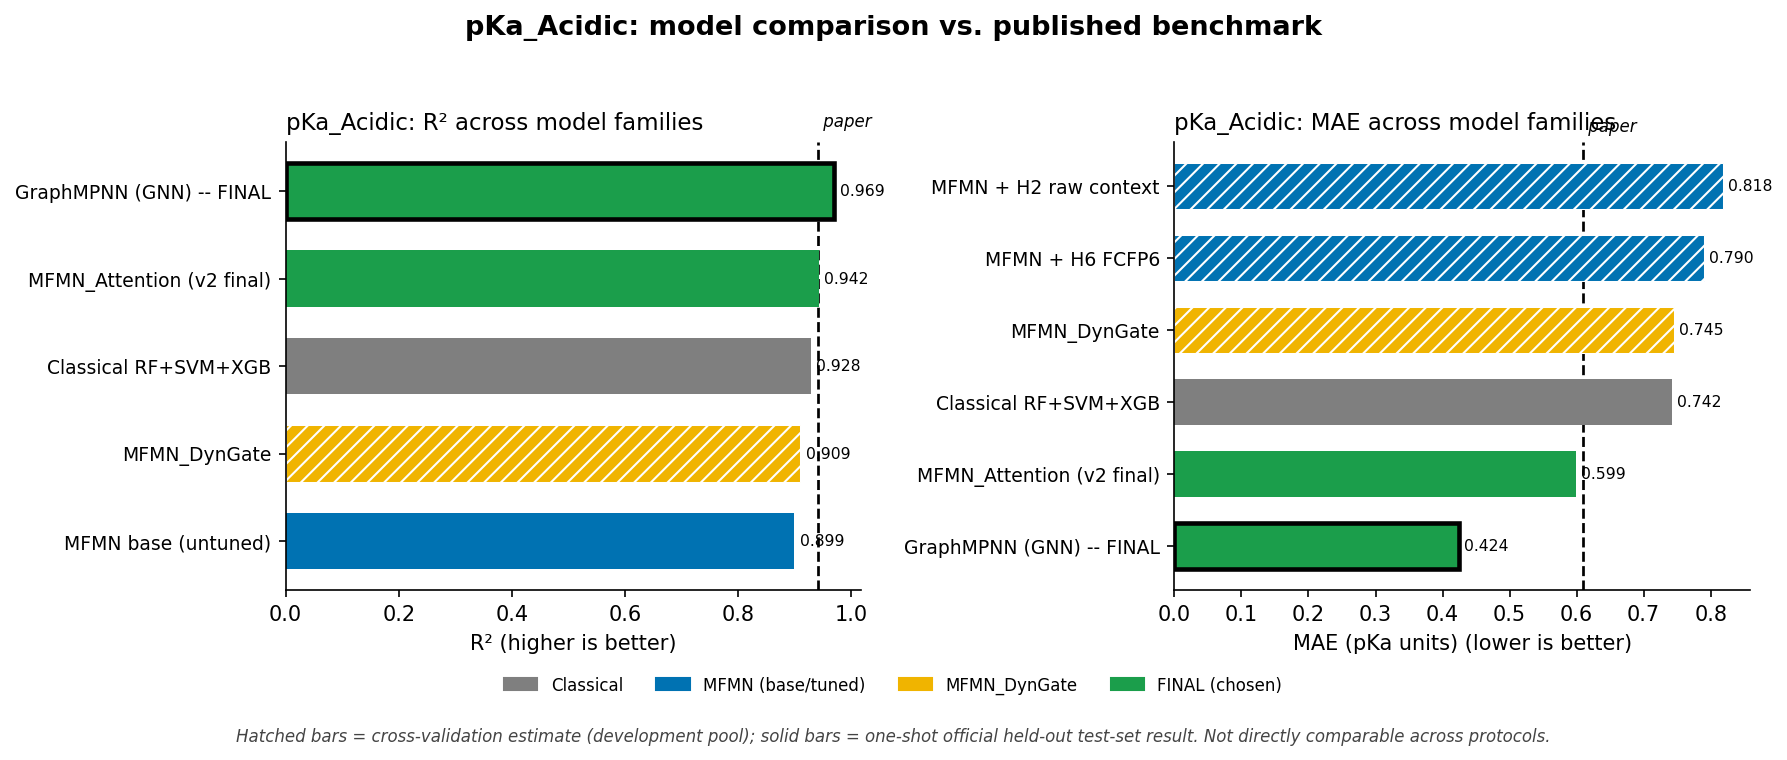

In [2]:
display(Image(filename="../figures/pKa_Acidic_comparison.png"))

### Full comparison table (with sources)

The table below includes the `source` column pointing to the exact result file each number
came from, for independent verification.


In [3]:
sub[["model", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "source"]].reset_index(drop=True)

,model,protocol,R2,MAE,RMSE,GMFE,within_2fold,source
0,GraphMPNN (GNN) -- FINAL,official-test,0.9689,0.4241,0.7571,NaN,NaN,mfmn_benchmark_package/outputs/01_pKa_Acidic_official_test_summary.csv (this session's fresh 10-seed rerun)
1,MFMN_Attention (v2 final),official-test,0.9421,0.5989,1.0329,NaN,NaN,mfmn/results/expv2_aux_campaign_final_attention_results.json
2,Paper (Jia et al. 2025),official-test,0.9400,0.6100,1.0500,NaN,NaN,PAPER dict (metrics.py)
3,Classical RF+SVM+XGB,official-test,0.9278,0.7421,1.1533,NaN,NaN,results/s2_aux_predictor_results.json
4,MFMN_DynGate,CV,0.9095,0.7448,NaN,NaN,NaN,mfmn/results/expv2_aux_h7_confirm_results.json (5-fold confirm)
5,MFMN base (untuned),official-test,0.8990,NaN,NaN,NaN,NaN,mfmn/deliverables/PROJECT_REPORT.md Section 4.2 (first transplant)
6,MFMN + H2 raw context,CV,NaN,0.8180,NaN,NaN,NaN,PROJECT_REPORT.md Table H2 (5-fold)
7,MFMN + H6 FCFP6,CV,NaN,0.7900,NaN,NaN,NaN,PROJECT_REPORT.md Table H6 (5-fold)
8,ChemBERTa embedding,CV,NaN,NaN,NaN,NaN,NaN,mfmn/results/expv2_aux_h10_chemberta_results.json (pKa_Acidic uses Attention arm)
